In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# This tells Python where to find your .py files
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))


# Induction Air Preheater — Energy Flexibility Model
## Industrial case study: evaporator
### University of Padova


In [18]:
import importlib
import config
import models.preheater
import models.simulation
import economics

importlib.reload(config)
importlib.reload(models.preheater)
importlib.reload(models.simulation)
importlib.reload(economics)
from config import AIR, PREHEATER, FURNACE, GAS, ECONOMICS
from models.preheater import PreheaterSteadyState
from models.simulation import AnnualSimulation, ThresholdController
from economics import lcoe_savings


## 1. System Description

The system consists of a natural gas evaporator that produces electricity though a turbine espansion where T_flame is constant, 
coupled with an induction air preheater. The preheater heats the combustion 
air before it enters the furnace, reducing gas consumption.
There will be a comparison between the system without the preheatewr and with a preheater

The dispatch strategy is based on electricity spot prices :
- **Preheater ON** when electricity price < threshold → save gas
- **Preheater OFF** when electricity price > threshold → furnace runs alone


## 2. Combustion & Air Flow Calculation
Starting from the evaporator thermal power, we calculate the gas consumption
and the required combustion air flow using stoichiometry.

In [ ]:
# Step 1 — Gas consumption of the furnace
Q_furnace_kw = FURNACE["Q_thermal"]        # kW
eta_furnace  = FURNACE["eta_furnace"]       # -
LHV_kj_per_kg = GAS["LHV"] * 1000         # kJ/kg (converting from MJ/kg)

m_dot_gas = (Q_furnace_kw) / (eta_furnace * LHV_kj_per_kg)  # kg/s

print(f"Furnace thermal power:  {Q_furnace_kw} kW")
print(f"Gas consumption:        {m_dot_gas:.4f} kg/s")
print(f"Gas consumption:        {m_dot_gas*3600:.2f} kg/h")

Furnace thermal power:  1500.0 kW
Gas consumption:        0.0400 kg/s
Gas consumption:        144.00 kg/h


In [20]:
# Step 2 — Stoichiometric air flow
AFR = 17.2          # [-] Air-to-Fuel Ratio for natural gas (stoichiometric)
excess_air = 1.10   # [-] 10% excess air (typical for industrial furnaces)

m_dot_air = m_dot_gas * AFR * excess_air  # kg/s

print(f"Air-to-fuel ratio:      {AFR} kg_air/kg_gas")
print(f"Excess air factor:      {excess_air}")
print(f"Air mass flow:          {m_dot_air:.4f} kg/s")
print(f"Air mass flow:          {m_dot_air*3600:.2f} kg/h")

Air-to-fuel ratio:      17.2 kg_air/kg_gas
Excess air factor:      1.1
Air mass flow:          0.7568 kg/s
Air mass flow:          2724.48 kg/h


In [21]:
# Step 3 — Heat required by the preheater
T_air_in  = AIR["T_in"]                    # [°C] from config (175°C)
delta_T   = PREHEATER["delta_T_target"]     # [°C] from config (200°C)
T_air_out = T_air_in + delta_T             # [°C] = 375°C

Q_preheater = m_dot_air * AIR["cp"] * delta_T  # [W]

print(f"Air temperature in:     {T_air_in} °C")
print(f"Air temperature out:    {T_air_out} °C")
print(f"Heat required:          {Q_preheater/1000:.2f} kW")

Air temperature in:     175.0 °C
Air temperature out:    375.0 °C
Heat required:          152.12 kW


In [22]:
# Step 4 — Electrical power required
eta_ind = PREHEATER["eta_ind"]       # [-] induction efficiency (0.92)

P_el_required = (Q_preheater / 1000) / eta_ind  # [kW]

print(f"Thermal power required: {Q_preheater/1000:.2f} kW")
print(f"Induction efficiency:   {eta_ind}")
print(f"Electrical power needed: {P_el_required:.2f} kW")

# Update config with calculated value
PREHEATER["P_el_max"] = P_el_required
print(f"\nPREHEATER['P_el_max'] updated to {P_el_required:.2f} kW")

Thermal power required: 152.12 kW
Induction efficiency:   0.92
Electrical power needed: 165.34 kW

PREHEATER['P_el_max'] updated to 165.34 kW


In [23]:
# Step 5 — Recalculate breakeven with real sizing
gas_price_eur_kwh = GAS["price"]

# Heat saved = heat delivered to air (same Q)
# Electrical power consumed = P_el_required
breakeven = (Q_preheater/1000 / P_el_required) * gas_price_eur_kwh * 1000

print(f"Heat saved per kW electrical: {Q_preheater/1000/P_el_required:.3f} kW_th/kW_el")
print(f"Breakeven electricity price:  {breakeven:.1f} €/MWh")

Heat saved per kW electrical: 0.920 kW_th/kW_el
Breakeven electricity price:  38.4 €/MWh


### Summary — Preheater Sizing
| Parameter | Value |
|-----------|-------|
| Gas consumption | 144 kg/h |
| Air mass flow | 2724 kg/h |
| Air temperature in | 175 °C |
| Air temperature out | 375 °C |
| Thermal power required | 152 kW |
| Electrical power required | 165 kW |
| Breakeven electricity price | 38.4 €/MWh |

## 3. Steady-State Operating Point
We verify the preheater performance at the nominal electrical power calculated from the sizing.

In [24]:
# Create preheater model and run at nominal power
ph = PreheaterSteadyState()
nominal = ph.run(P_el_required)

print("Nominal operating point:")
for key, value in nominal.items():
    print(f"  {key:<25} {value:.2f}")

KeyError: 'm_dot'

## 4. Dynamic Model — Thermal Ramp
The preheater does not switch on instantaneously. The susceptor takes a few minutes to reach operating temperature. We model this with a first-order lag:

$$\tau \frac{dQ}{dt} = Q_{target} - Q_{current}$$

Where $\tau$ is the thermal time constant (minutes).

In [ ]:
from models.preheater import PreheaterDynamic

# Create dynamic model with 1 minute time step
ph_dyn = PreheaterDynamic(dt_min=1.0)

# Simulate 60 min ON, then 60 min OFF
n_steps = 120
time_min  = np.arange(n_steps)
Q_history = np.zeros(n_steps)
T_history = np.zeros(n_steps)

for i in range(n_steps):
    P_target = PREHEATER["P_el_max"] if i < 60 else 0.0
    state = ph_dyn.step(P_target)
    Q_history[i] = state["Q_current_kw"]
    T_history[i] = state["T_air_out"]

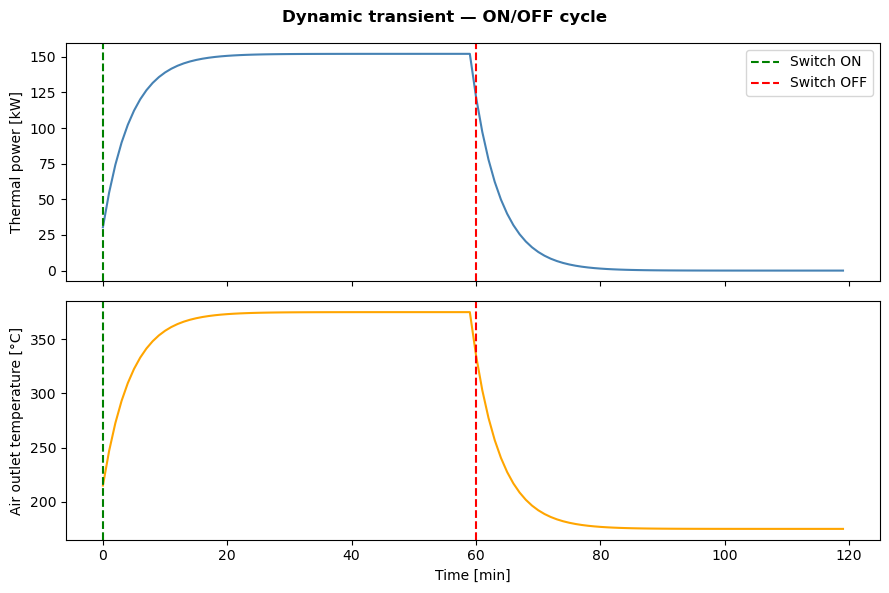

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
fig.suptitle("Dynamic transient — ON/OFF cycle", fontweight="bold")

ax1.plot(time_min, Q_history, color="steelblue")
ax1.axvline(0,  color="green", linestyle="--", label="Switch ON")
ax1.axvline(60, color="red",   linestyle="--", label="Switch OFF")
ax1.set_ylabel("Thermal power [kW]")
ax1.legend()

ax2.plot(time_min, T_history, color="orange")
ax2.axvline(0,  color="green", linestyle="--")
ax2.axvline(60, color="red",   linestyle="--")
ax2.set_ylabel("Air outlet temperature [°C]")
ax2.set_xlabel("Time [min]")

plt.tight_layout()
plt.show()

## 5. Annual Simulation
We simulate the system over a full year (8760 hours) using GEM electricity spot prices.

The dispatch strategy is a simple threshold controller:
- **Preheater ON** if price < threshold (€/MWh)
- **Preheater OFF** if price > threshold (€/MWh)

The threshold is set at 36.8 €/MWh (placeholder — to be optimized).

In [ ]:
prices_raw = pd.read_csv(
    "data/Hourly_electricity_price.csv",
    sep=";",
    decimal=",",
    skiprows=1,        # skip the "Table 1" header row
    usecols=[0, 1, 2], # ignore the empty columns at the end
    names=["date", "hour", "price_eur_mwh"],  # rename columns to clean names
    header=0,
)

print(prices_raw.head(10))
print(f"\nShape: {prices_raw.shape}")
print(f"\nData types:\n{prices_raw.dtypes}")

         date  hour  price_eur_mwh
0  01/01/2025     1         138.70
1  01/01/2025     2         134.06
2  01/01/2025     3         134.41
3  01/01/2025     4         131.99
4  01/01/2025     5         131.99
5  01/01/2025     6         131.99
6  01/01/2025     7         138.00
7  01/01/2025     8         140.15
8  01/01/2025     9         136.62
9  01/01/2025    10         129.82

Shape: (8760, 3)

Data types:
date              object
hour               int64
price_eur_mwh    float64
dtype: object


In [ ]:
# Convert date and hour to a proper timestamp
prices_raw["timestamp"] = pd.to_datetime(
    prices_raw["date"], format="%d/%m/%Y"
) + pd.to_timedelta(prices_raw["hour"] - 1, unit="h")

# Keep only the columns we need
prices_df_real = prices_raw[["timestamp", "price_eur_mwh"]].copy()

print(prices_df_real.head(5))
print(f"\nDate range: {prices_df_real['timestamp'].min()} → {prices_df_real['timestamp'].max()}")
print(f"Mean price: {prices_df_real['price_eur_mwh'].mean():.1f} €/MWh")
print(f"Min price:  {prices_df_real['price_eur_mwh'].min():.1f} €/MWh")
print(f"Max price:  {prices_df_real['price_eur_mwh'].max():.1f} €/MWh")

            timestamp  price_eur_mwh
0 2025-01-01 00:00:00         138.70
1 2025-01-01 01:00:00         134.06
2 2025-01-01 02:00:00         134.41
3 2025-01-01 03:00:00         131.99
4 2025-01-01 04:00:00         131.99

Date range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00
Mean price: 115.9 €/MWh
Min price:  0.0 €/MWh
Max price:  289.0 €/MWh


In [ ]:
ECONOMICS["el_price_threshold"] = breakeven

sim = AnnualSimulation(
    controller=ThresholdController(
        threshold_eur_mwh=ECONOMICS["el_price_threshold"]
    )
)

print(f"Control threshold set to: {ECONOMICS['el_price_threshold']:.1f} €/MWh")

Control threshold set to: 38.4 €/MWh


In [ ]:
# Run simulation with real Italian prices
results_df = sim.run(prices_df_real)

# Quick summary
hours_on  = results_df["preheater_on"].sum()
hours_off = (~results_df["preheater_on"]).sum()

print(f"Preheater ON:  {hours_on} hours ({hours_on/8760*100:.1f}%)")
print(f"Preheater OFF: {hours_off} hours ({hours_off/8760*100:.1f}%)")
print(f"\nTotal net saving: {results_df['net_saving_eur'].sum():.0f} €/year")

Preheater ON:  223 hours (2.5%)
Preheater OFF: 8537 hours (97.5%)

Total net saving: 1223 €/year
